In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('../../../data/online+retail/Online Retail.xlsx')
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [5]:
df = df.dropna()
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [6]:
df['total_price'] = df['Quantity'] * df['UnitPrice']

In [7]:
df = df[df['total_price'] > 0]


In [8]:
df_pedidos = df.groupby(
    ['CustomerID', 'InvoiceNo', 'InvoiceDate'],
    as_index=False
).agg({
    'total_price': 'sum'
})

df_pedidos.head(5)


,CustomerID,InvoiceNo,InvoiceDate,total_price
0,12346.0,541431,2011-01-18 10:01:00,77183.60
1,12347.0,537626,2010-12-07 14:57:00,711.79
2,12347.0,542237,2011-01-26 14:30:00,475.39
3,12347.0,549222,2011-04-07 10:43:00,636.25
4,12347.0,556201,2011-06-09 13:01:00,382.52


In [9]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,total_price
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [10]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
total_price           float64
dtype: object

# **AJUSTAR AL MODELO DE DATOS**

In [ ]:
import pandas as pd 
import numpy as np
from difflib import SequenceMatcher
from datetime import datetime


class DatasetMapper:
    """
    Mapea automáticamente columnas de un dataset a un esquema objetivo
    usando similitud de texto y validación de tipos de datos.
    """
    
    def __init__(self):
        # Modelo de datos objetivo para segmentación de clientes
        self.target_schema = {
            'id_usuario': {
                'type': 'string',
                'aliases': ['user_id', 'usuario', 'cliente', 'customer_id', 
                           'client_id', 'user', 'cliente_id', 'id_cliente']
            },
            'id_pedido': {
                'type': 'string',
                'aliases': ['order_id', 'pedido', 'orden', 'order', 
                           'num_pedido', 'numero_pedido', 'id_orden']
            },
            'total_pedido': {
                'type': 'number',
                'aliases': ['total', 'amount', 'importe', 'total_price', 'totalprice',
                           'monto', 'valor', 'total_order', 'importe_total', 'total_amount',
                           'order_total', 'order_amount', 'invoice_total', 'grand_total']
            },
            'fecha_pedido': {
                'type': 'date',
                'aliases': ['fecha', 'date', 'created_at', 'order_date', 
                           'fecha_orden', 'timestamp', 'fecha_creacion']
            }
        }
    
    def _calculate_similarity(self, str1, str2):
        """Calcula similitud entre dos strings"""
        str1 = str1.lower().replace('_', '').replace('-', '').replace(' ', '')
        str2 = str2.lower().replace('_', '').replace('-', '').replace(' ', '')
        
        # Coincidencia exacta
        if str1 == str2:
            return 1.0
        
        # Contiene
        if str1 in str2 or str2 in str1:
            return 0.85
        
        # Similitud de secuencia
        return SequenceMatcher(None, str1, str2).ratio()
    
    def _validate_type(self, series, expected_type):
        """Valida que una serie coincida con el tipo esperado"""
        if len(series) == 0:
            return 0.5
        
        # Tomar muestra de valores no nulos
        sample = series.dropna().head(10)
        if len(sample) == 0:
            return 0.5
        
        valid_count = 0
        
        for value in sample:
            if expected_type == 'number':
                try:
                    float(value)
                    valid_count += 1
                except (ValueError, TypeError):
                    pass
            
            elif expected_type == 'date':
                if self._is_date(value):
                    valid_count += 1
            
            elif expected_type == 'string':
                if isinstance(value, (str, int, float)):
                    valid_count += 1
        
        return valid_count / len(sample)
    
    def _is_date(self, value):
        """Verifica si un valor es una fecha"""
        if pd.isna(value):
            return False
        
        # Si ya es datetime
        if isinstance(value, (pd.Timestamp, datetime)):
            return True
        
        # Intentar parsear como fecha
        try:
            pd.to_datetime(value)
            return True
        except:
            return False
    
    def auto_map(self, df, confidence_threshold=0.5):
        """
        Mapea automáticamente las columnas del dataframe al esquema objetivo
        
        Args:
            df: DataFrame a mapear
            confidence_threshold: Umbral mínimo de confianza (0-1)
        
        Returns:
            dict: Mapeo {columna_objetivo: columna_original}
        """
        # Primero calculamos todos los scores posibles
        all_scores = {}
        
        for target_col, config in self.target_schema.items():
            all_scores[target_col] = {}
            
            for source_col in df.columns:
                # Calcular similitud con el nombre objetivo
                score = self._calculate_similarity(source_col, target_col)
                
                # Calcular similitud con aliases
                for alias in config['aliases']:
                    alias_score = self._calculate_similarity(source_col, alias)
                    score = max(score, alias_score)
                
                # Validar tipo de dato
                type_validity = self._validate_type(df[source_col], config['type'])
                
                # Score final ponderado
                final_score = score * 0.7 + type_validity * 0.3
                
                if final_score >= confidence_threshold:
                    all_scores[target_col][source_col] = final_score
        
        # Asignar columnas evitando duplicados (cada columna solo se asigna una vez)
        mapping = {}
        confidence_scores = {}
        used_columns = set()
        
        # Ordenar por mejor score para asignar primero los matches más seguros
        candidates = []
        for target_col, scores in all_scores.items():
            for source_col, score in scores.items():
                candidates.append((score, target_col, source_col))
        
        candidates.sort(reverse=True, key=lambda x: x[0])
        
        # Asignar columnas de mayor a menor confianza
        for score, target_col, source_col in candidates:
            # Solo asignar si la columna fuente no ha sido usada y el target no tiene asignación
            if source_col not in used_columns and target_col not in mapping:
                mapping[target_col] = source_col
                confidence_scores[target_col] = score
                used_columns.add(source_col)
        
        return mapping, confidence_scores
    
    def transform(self, df, mapping=None, auto_map_threshold=0.5):
        """
        Transforma el dataframe al esquema objetivo
        
        Args:
            df: DataFrame a transformar
            mapping: Mapeo manual opcional {col_objetivo: col_original}
            auto_map_threshold: Umbral para mapeo automático si no se provee mapping
        
        Returns:
            DataFrame transformado con las columnas objetivo
        """
        if mapping is None:
            mapping, scores = self.auto_map(df, auto_map_threshold)
            print("Mapeo automático:")
            for target, source in mapping.items():
                print(f"  {target} <- {source} (confianza: {scores[target]:.2f})")
        
        # Verificar columnas faltantes
        missing = set(self.target_schema.keys()) - set(mapping.keys())
        if missing:
            print(f"\n⚠️ Advertencia: Columnas no mapeadas: {missing}")
        
        # Crear nuevo dataframe con columnas mapeadas
        result = pd.DataFrame()
        
        for target_col, source_col in mapping.items():
            result[target_col] = df[source_col].copy()
            
            # Convertir tipos
            expected_type = self.target_schema[target_col]['type']
            
            if expected_type == 'number':
                result[target_col] = pd.to_numeric(result[target_col], errors='coerce')
            elif expected_type == 'date':
                result[target_col] = pd.to_datetime(result[target_col], errors='coerce')
            elif expected_type == 'string':
                result[target_col] = result[target_col].astype(str)
        
        return result

In [12]:
# Opción 1: Mapeo automático
mapper = DatasetMapper()
df_limpio = mapper.transform(df)

Mapeo automático:
  id_usuario <- CustomerID (confianza: 1.00)
  total_pedido <- total_price (confianza: 1.00)
  fecha_pedido <- InvoiceDate (confianza: 0.90)
  id_pedido <- InvoiceNo (confianza: 0.65)


In [13]:
df_limpio.head(5)

,id_usuario,total_pedido,fecha_pedido,id_pedido
0,17850.0,15.30,2010-12-01 08:26:00,536365
1,17850.0,20.34,2010-12-01 08:26:00,536365
2,17850.0,22.00,2010-12-01 08:26:00,536365
3,17850.0,20.34,2010-12-01 08:26:00,536365
4,17850.0,20.34,2010-12-01 08:26:00,536365


In [14]:
df_pedidos = df_limpio.groupby(
    ['id_usuario', 'id_pedido', 'fecha_pedido'],
    as_index=False
).agg({
    'total_pedido': 'sum'
})

df_pedidos.head(5)

,id_usuario,id_pedido,fecha_pedido,total_pedido
0,12346.0,541431,2011-01-18 10:01:00,77183.60
1,12347.0,537626,2010-12-07 14:57:00,711.79
2,12347.0,542237,2011-01-26 14:30:00,475.39
3,12347.0,549222,2011-04-07 10:43:00,636.25
4,12347.0,556201,2011-06-09 13:01:00,382.52


In [15]:
df_pedidos = df_pedidos[df_pedidos['total_pedido'] > 0]
df_pedidos.size

74248

In [16]:
fecha_referencia = df_limpio['fecha_pedido'].max() + pd.Timedelta(days=1)

In [17]:
rfm = df_pedidos.groupby('id_usuario').agg(
    Recency=('fecha_pedido', lambda x: (fecha_referencia - x.max()).days),
    Frequency=('id_pedido', 'nunique'),
    Monetary=('total_pedido', 'sum')
).reset_index()

rfm.head(5)

,id_usuario,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


# Evaluación Pre-Segmentación

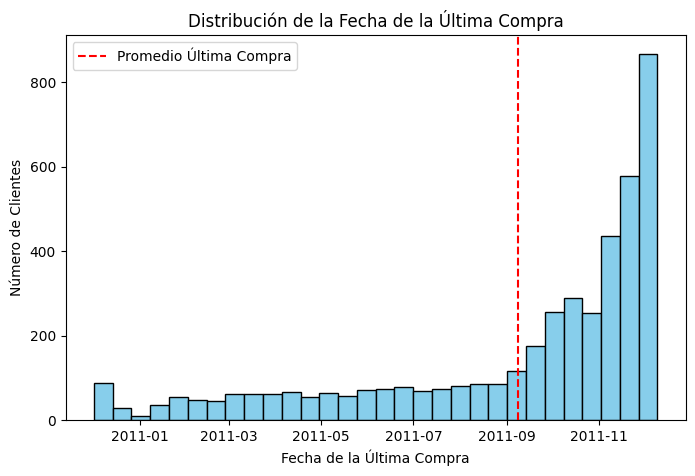

In [18]:
promedio_ultima_compra = df_limpio['fecha_pedido'].max() - pd.to_timedelta(rfm['Recency'].mean(), unit='D')
plt.figure(figsize=(8,5))
plt.axvline(promedio_ultima_compra, color='r', linestyle='--', label='Promedio Última Compra')
plt.hist(df_pedidos.groupby('id_usuario')['fecha_pedido'].max(), bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de la Fecha de la Última Compra')
plt.xlabel('Fecha de la Última Compra')
plt.ylabel('Número de Clientes')
plt.legend()
plt.show()

# **PUNTUACIONES RFM**

# Por quantiles

In [19]:
def rfm_quantiles(dataframe):
    """
    - Recencia -> 5 = más reciente, 1 = menos reciente
    - Frecuencia -> 5 = más frecuente, 1 = menos frecuente
    - Monetario -> 5 = mayor gasto, 1 = menor gasto
    """
    dataframe["Recency_score"] = pd.qcut(dataframe["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
    dataframe["Frequency_score"] = pd.qcut(dataframe["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
    dataframe["Monetary_score"] = pd.qcut(dataframe["Monetary"], 5, labels=[1,2,3,4,5]).astype(int)

    dataframe["RFM_Score"] = dataframe["Recency_score"].astype(str) + dataframe["Frequency_score"].astype(str) + dataframe["Monetary_score"].astype(str)
    return dataframe

rfm_scores = rfm_quantiles(rfm)
rfm_scores.head(5)

,id_usuario,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_Score
0,12346.0,326,1,77183.60,1,1,5,115
1,12347.0,2,7,4310.00,5,5,5,555
2,12348.0,75,4,1797.24,2,4,4,244
3,12349.0,19,1,1757.55,4,1,4,414
4,12350.0,310,1,334.40,1,1,2,112


# **CLASIFICACIÓN DE CLIENTES**

In [20]:
mapa_segmentos = {
    r'[4-5][4-5][4-5]':'Champions',
    r'[2-3][4-5][4-5]':'Loyal Customers',
    r'[4-5][2-5][4-5]':'Potential Loyalists',
    r'[4-5][2-5][1-3]':'Recent Customers',
    r'[2-3][2-3][4-5]':'Ocasional Customers',
    r'[2-4][1-5][1-4]':'Potential Customers',
    r'[2-3][4-5][2-3]': 'Economic Loyalists',
    r'[1][4-5][4-5]':'Risky Customers',
    r'[1-2][1-3][4-5]':'Nearly Lost',
    r'[1-2][4-5][1-3]':'Need Attention',
    r'[3-4][1-3][1-3]':'Average Customers',
    r'[1-3][1-3][1-3]':'Non active',
    r'[1-3][1-3][1-2]':'Sleeping',
    r'[4-5][1][1-5]': 'New Customers',
    r'[1][1][1]': 'Lost',
}

rfm["Segmento"] = rfm['RFM_Score'].replace(mapa_segmentos, regex=True)
rfm

,id_usuario,Recency,Frequency,Monetary,Recency_score,Frequency_score,Monetary_score,RFM_Score,Segmento
0,12346.0,326,1,77183.60,1,1,5,115,Nearly Lost
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1797.24,2,4,4,244,Loyal Customers
3,12349.0,19,1,1757.55,4,1,4,414,Potential Customers
4,12350.0,310,1,334.40,1,1,2,112,Non active
...,...,...,...,...,...,...,...,...,...
4333,18280.0,278,1,180.60,1,2,1,121,Non active
4334,18281.0,181,1,80.82,1,2,1,121,Non active
4335,18282.0,8,2,178.05,5,3,1,531,Recent Customers
4336,18283.0,4,16,2094.88,5,5,5,555,Champions


In [21]:
import seaborn as sns

/var/folders/w2/64z011j921sfnr8gdccq0yy40000gn/T/ipykernel_5461/2867317298.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Segmento', palette='viridis', ax=ax)


<Figure size 1000x600 with 0 Axes>

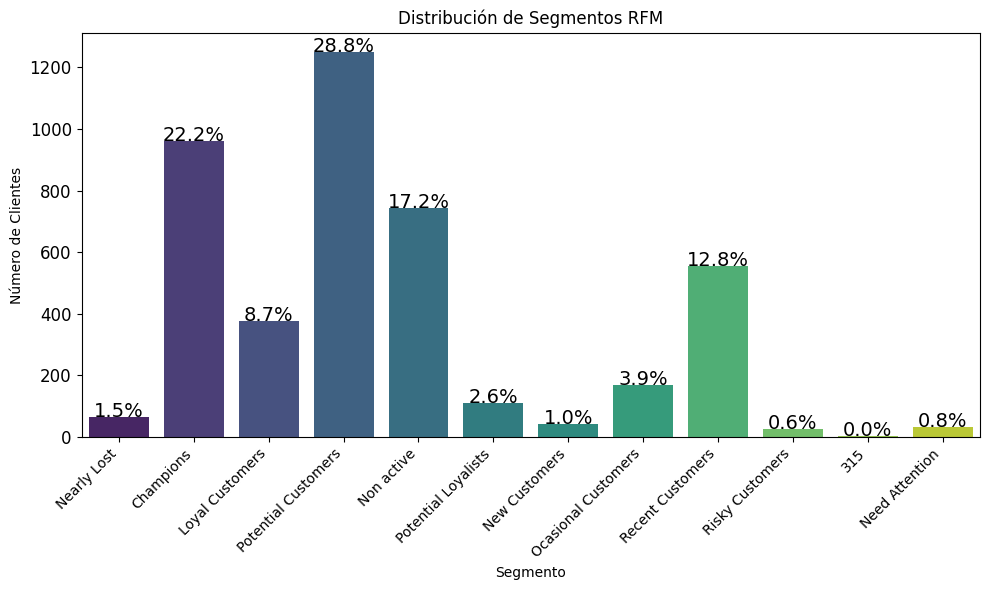

In [22]:
plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(data=rfm, x='Segmento', palette='viridis', ax=ax)
total = len(rfm.Segmento)
for patch in ax.patches:
    percentage = '{:.1f}%'.format(100 * patch.get_height() / total)
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_y() + patch.get_height()
    ax.annotate(percentage, (x, y), ha='center', size=14)

plt.title('Distribución de Segmentos RFM')
plt.xlabel('Segmento')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45, ha='right')
plt.yticks(size=12)
plt.tight_layout()
plt.show()

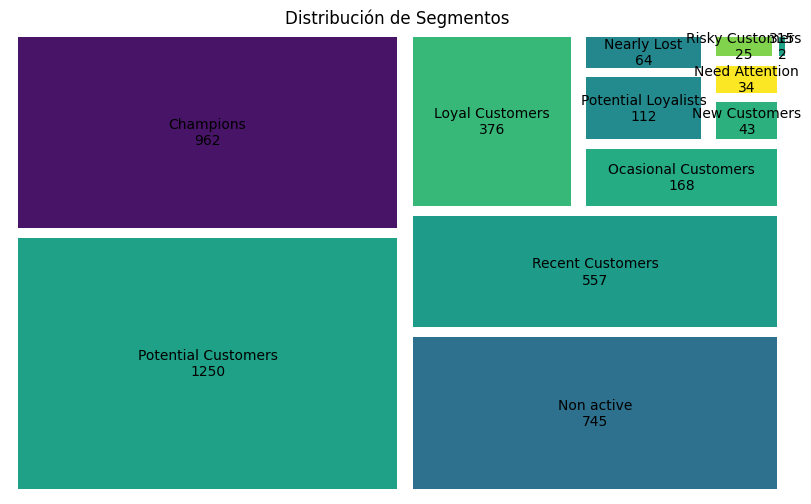

In [23]:
import matplotlib.pyplot as plt
import squarify

# Conteo de segmentos
x = rfm["Segmento"].value_counts()

plt.figure(figsize=(10, 6))
squarify.plot(
    sizes=x.values,
    label=[f"{seg}\n{val}" for seg, val in zip(x.index, x.values)],
    pad=True
)
plt.axis("off")
plt.title("Distribución de Segmentos")
plt.show()


# CLUSTERING

In [24]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Definir rango de búsqueda y variables para almacenar resultados
K = range(2, 11)
silhouettes = []

# 2. Calcular Silhouette Score para cada K
for k in K:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouettes.append(score)
    print(f"K={k} -> Silhouette Score: {score:.4f}")

# 3. Selección automática del K óptimo (el valor máximo)
k_optimo_seguro = K[silhouettes.index(max(silhouettes))]
print(f"\n--- Resultado Automático ---")
print(f"El número óptimo de clusters basado en Silhouette es: {k_optimo_seguro}")

# 4. Ejecución del Clustering Final
kmeans_final = KMeans(n_clusters=k_optimo_seguro, random_state=42, n_init=10)
rfm['K_Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# 5. Visualización de la curva de validación
plt.figure(figsize=(8, 4))
plt.plot(K, silhouettes, 'bo-')
plt.axvline(x=k_optimo_seguro, color='red', linestyle='--', label=f'Óptimo (K={k_optimo_seguro})')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Selección Automática de Clusters vía Silhouette')
plt.legend()
plt.show()

NameError: name 'rfm_scaled' is not defined